# EMC Event Reservation - Forecasting Models

This notebook covers:
1. Loading the cleaned monthly time series
2. Stationarity test (ADF Test) - required for SARIMA
3. Train / Test split (18 months train, 4 months test)
4. Building 5 forecasting models:
   - Model 1: Moving Average
   - Model 2: Linear Regression
   - Model 3: SARIMA
   - Model 4: Seasonal Naive
   - Model 5: Holt-Winters (Exponential Smoothing)
5. Computing MAE and RMSE for each model
6. Final comparison table and winner

**Input file:** `EMC_Monthly_Reservations.csv`

## Step 1: Install & Import Libraries

In [2]:
# Install required libraries if not already installed
# Run this cell once, then you can skip it on future runs
import subprocess
subprocess.run(['pip', 'install', 'statsmodels', 'scikit-learn', '--quiet'], check=False)
print('Libraries ready.')

Libraries ready.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Stats & ML
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('All libraries imported successfully.')

All libraries imported successfully.


## Step 2: Load the Monthly Reservation Data

In [4]:
# Use the cleaned monthly dataset generated during preprocessing
FILE_PATH = 'EMC_Monthly_Reservations_Cleaned.csv'

df = pd.read_csv(FILE_PATH)
df['month'] = pd.to_datetime(df['month'])
df = df.set_index('month')
df.index.freq = 'MS'  # Monthly start frequency

print(f'Loaded {len(df)} months of data')
print(f'Date range: {df.index[0].strftime("%b %Y")}  ->  {df.index[-1].strftime("%b %Y")}')
print()
print(df)

Loaded 27 months of data
Date range: Jan 2024  ->  Mar 2026

            reservation_count
month                        
2024-01-01                  2
2024-02-01                  0
2024-03-01                  5
2024-04-01                 13
2024-05-01                  9
2024-06-01                  3
2024-07-01                  8
2024-08-01                 21
2024-09-01                 19
2024-10-01                 17
2024-11-01                 10
2024-12-01                 10
2025-01-01                  4
2025-02-01                 17
2025-03-01                 23
2025-04-01                 16
2025-05-01                  7
2025-06-01                  6
2025-07-01                  9
2025-08-01                  8
2025-09-01                 21
2025-10-01                 13
2025-11-01                  8
2025-12-01                  7
2026-01-01                 15
2026-02-01                 13
2026-03-01                 10


## Step 3: Visualize the Full Time Series

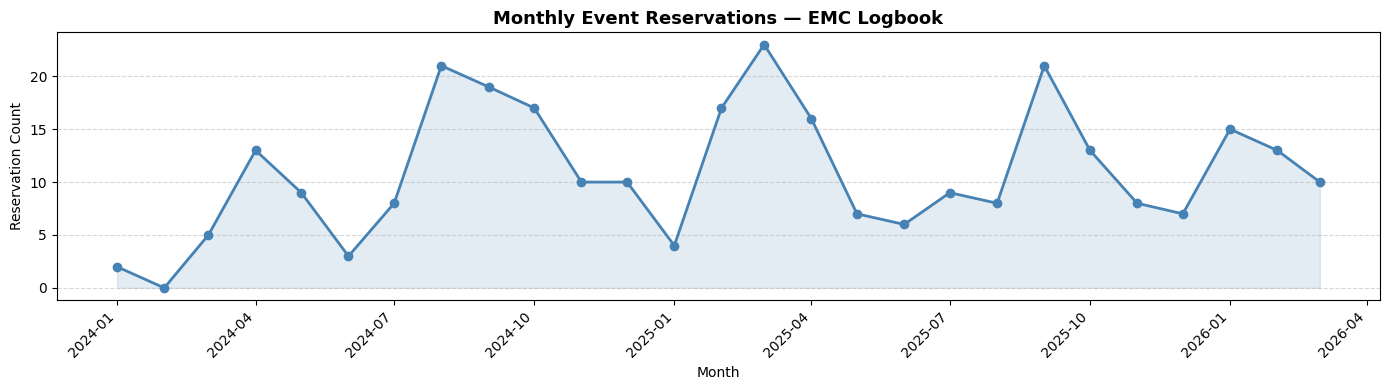

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['reservation_count'], marker='o', color='steelblue', linewidth=2)
ax.fill_between(df.index, df['reservation_count'], alpha=0.15, color='steelblue')
ax.set_title('Monthly Event Reservations — EMC Logbook', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_full_series.png', dpi=150)
plt.show()

## Step 4: Stationarity Test (ADF Test)

**Why:** SARIMA requires the data to be stationary (stable mean and variance over time).

**Interpretation:**
- p-value < 0.05 → Data IS stationary → SARIMA can proceed as-is
- p-value ≥ 0.05 → Data is NOT stationary → We apply differencing (d=1) in SARIMA parameters

In [6]:
def run_adf_test(series, label='Series'):
    result = adfuller(series.dropna())
    print(f'=== ADF Test: {label} ===')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Critical Values:')
    for key, val in result[4].items():
        print(f'    {key}: {val:.4f}')
    if result[1] < 0.05:
        print('  STATIONARY (p < 0.05) — SARIMA can proceed as-is')
        return True
    else:
        print('   NOT STATIONARY (p ≥ 0.05) — Use d=1 in SARIMA to difference the data')
        return False

is_stationary = run_adf_test(df['reservation_count'], 'Monthly Reservations')

=== ADF Test: Monthly Reservations ===
  ADF Statistic : -2.9409
  p-value       : 0.0408
  Critical Values:
    1%: -3.8326
    5%: -3.0312
    10%: -2.6555
  STATIONARY (p < 0.05) — SARIMA can proceed as-is


In [7]:
# If not stationary, also test the differenced series (for reference)
if not is_stationary:
    print()
    print('Testing differenced series (lag-1):')
    run_adf_test(df['reservation_count'].diff(), 'Differenced Series')
    print()
    print('→ We will set d=1 in our SARIMA model to handle non-stationarity automatically.')
else:
    print()
    print('→ We will set d=0 in our SARIMA model (no differencing needed).')


→ We will set d=0 in our SARIMA model (no differencing needed).


## Step 5: Train / Test Split

We split the 22 months of data as follows:
- **Training set:** First 18 months (Jan 2024 – Jun 2025) — models learn from this
- **Test set:** Last 4 months (Jul 2025 – Oct 2025) — we evaluate predictions against this

This is an 82% / 18% split, which is standard for short time series.

In [8]:
TEST_SIZE = 4  # number of months held out for testing

train = df.iloc[:-TEST_SIZE]
test  = df.iloc[-TEST_SIZE:]

print(f'Training set : {len(train)} months  ({train.index[0].strftime("%b %Y")} → {train.index[-1].strftime("%b %Y")})')
print(f'Test set     : {len(test)} months  ({test.index[0].strftime("%b %Y")} → {test.index[-1].strftime("%b %Y")})')
print()
print('Training data:')
print(train)
print()
print('Test data (what we will predict):')
print(test)

Training set : 23 months  (Jan 2024 → Nov 2025)
Test set     : 4 months  (Dec 2025 → Mar 2026)

Training data:
            reservation_count
month                        
2024-01-01                  2
2024-02-01                  0
2024-03-01                  5
2024-04-01                 13
2024-05-01                  9
2024-06-01                  3
2024-07-01                  8
2024-08-01                 21
2024-09-01                 19
2024-10-01                 17
2024-11-01                 10
2024-12-01                 10
2025-01-01                  4
2025-02-01                 17
2025-03-01                 23
2025-04-01                 16
2025-05-01                  7
2025-06-01                  6
2025-07-01                  9
2025-08-01                  8
2025-09-01                 21
2025-10-01                 13
2025-11-01                  8

Test data (what we will predict):
            reservation_count
month                        
2025-12-01                  7
2026-01-01    

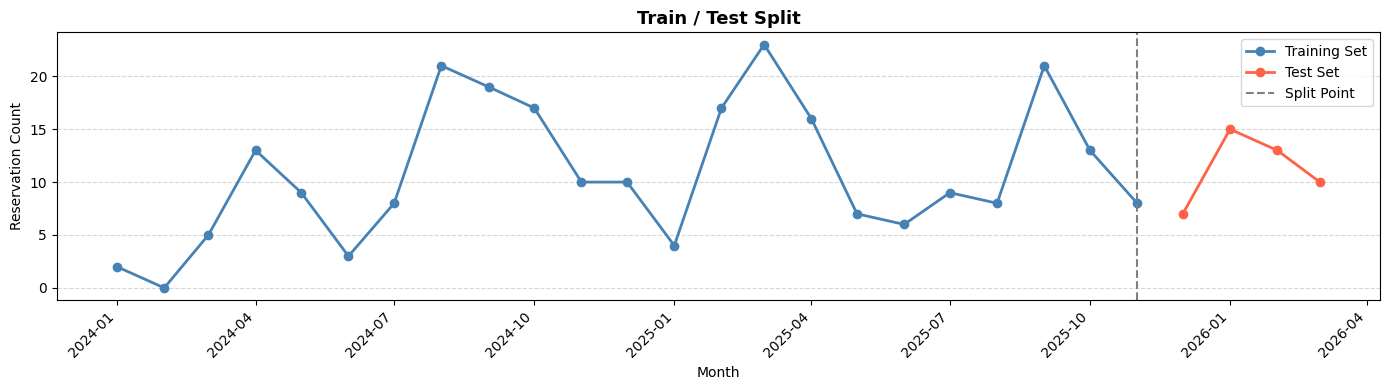

In [9]:
# Visualize the split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['reservation_count'], marker='o', color='steelblue',
        linewidth=2, label='Training Set')
ax.plot(test.index, test['reservation_count'], marker='o', color='tomato',
        linewidth=2, label='Test Set')
ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1.5, label='Split Point')
ax.set_title('Train / Test Split', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_train_test_split.png', dpi=150)
plt.show()

## Step 6: Helper — Expanded Forecast Metrics

In [10]:
def compute_errors(actual, predicted, model_name):
    """Compute MAE, RMSE, MASE, Direction Accuracy, Variance Ratio, and Pearson correlation."""
    actual_arr = np.array(actual, dtype=float)
    pred_arr = np.array(predicted, dtype=float)

    mae  = mean_absolute_error(actual_arr, pred_arr)
    rmse = np.sqrt(mean_squared_error(actual_arr, pred_arr))

    # MASE uses naive one-step scale from training data
    train_vals = train['reservation_count'].values.astype(float)
    naive_scale = np.mean(np.abs(np.diff(train_vals))) if len(train_vals) > 1 else np.nan
    mase = mae / naive_scale if naive_scale and naive_scale > 0 else np.nan

    # Directional Accuracy
    dirs_a = np.sign(np.diff(actual_arr))
    dirs_p = np.sign(np.diff(pred_arr))
    dir_acc = np.mean(dirs_a == dirs_p) * 100 if len(dirs_a) > 0 else np.nan

    # Variance Ratio and Pearson correlation
    var_actual = np.var(actual_arr)
    var_pred = np.var(pred_arr)
    var_ratio = (var_pred / var_actual) if var_actual > 0 else np.nan
    pearson_r = np.corrcoef(actual_arr, pred_arr)[0, 1] if (np.std(actual_arr) > 0 and np.std(pred_arr) > 0) else np.nan

    print(f'  MAE      = {mae:.4f}   (avg absolute error per month)')
    print(f'  RMSE     = {rmse:.4f}   (penalizes large errors more)')
    print(f'  MASE     = {mase:.4f}' if not np.isnan(mase) else '  MASE     = NaN')
    print(f'  Dir.Acc% = {dir_acc:.1f}%' if not np.isnan(dir_acc) else '  Dir.Acc% = NaN')
    print(f'  Var.Ratio= {var_ratio:.4f}' if not np.isnan(var_ratio) else '  Var.Ratio= NaN')
    print(f'  PearsonR = {pearson_r:.4f}' if not np.isnan(pearson_r) else '  PearsonR = NaN')

    return {
        'Model': model_name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'MASE': round(mase, 4) if not np.isnan(mase) else np.nan,
        'Dir.Acc%': round(dir_acc, 1) if not np.isnan(dir_acc) else np.nan,
        'Var.Ratio': round(var_ratio, 4) if not np.isnan(var_ratio) else np.nan,
        'Pearson R': round(pearson_r, 4) if not np.isnan(pearson_r) else np.nan,
    }

# Store results from all models here
results = []

---
## Model 1: Moving Average

**How it works:** Predicts the next month as the average of the last N months (rolling window).

**Best for:** Smoothing out noise. Good simple baseline.

In [11]:
# Window size tuned by rolling CV
MA_WINDOW = 2

# Generate predictions for each test month
# For each test step, we average the last MA_WINDOW months from training + already-predicted months
history = list(train['reservation_count'].values)
ma_predictions = []

for i in range(TEST_SIZE):
    window_avg = np.mean(history[-MA_WINDOW:])
    ma_predictions.append(window_avg)
    # Use actual test value as next step's history (walk-forward)
    history.append(test['reservation_count'].iloc[i])

ma_pred_series = pd.Series(ma_predictions, index=test.index)

print(f'=== Model 1: Moving Average (window={MA_WINDOW}) ===')
print(f'  Month       Actual   Predicted')
for i, idx in enumerate(test.index):
    print(f'  {idx.strftime("%b %Y")}    {test["reservation_count"].iloc[i]:>6}   {ma_predictions[i]:>9.2f}')
print()
ma_result = compute_errors(test['reservation_count'], ma_predictions, f'Moving Average (w={MA_WINDOW})')
results.append(ma_result)

=== Model 1: Moving Average (window=2) ===
  Month       Actual   Predicted
  Dec 2025         7       10.50
  Jan 2026        15        7.50
  Feb 2026        13       11.00
  Mar 2026        10       14.00

  MAE      = 4.2500   (avg absolute error per month)
  RMSE     = 4.7037   (penalizes large errors more)
  MASE     = 0.7421
  Dir.Acc% = 0.0%
  Var.Ratio= 0.5782
  PearsonR = -0.5278


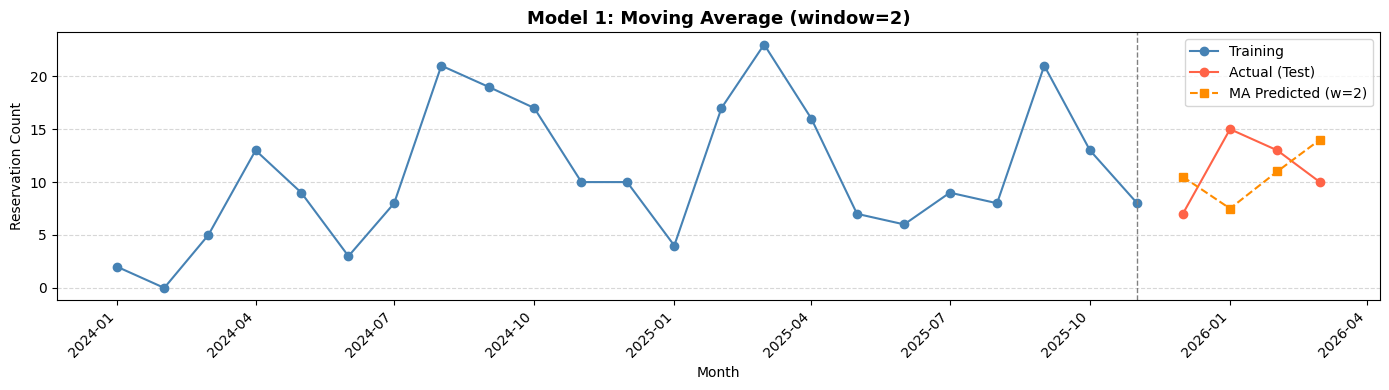

In [12]:
# Plot Moving Average predictions vs actuals
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['reservation_count'], marker='o', color='steelblue', label='Training')
ax.plot(test.index, test['reservation_count'], marker='o', color='tomato', label='Actual (Test)')
ax.plot(test.index, ma_pred_series, marker='s', linestyle='--', color='darkorange', label=f'MA Predicted (w={MA_WINDOW})')
ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1)
ax.set_title(f'Model 1: Moving Average (window={MA_WINDOW})', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_model1_moving_average.png', dpi=150)
plt.show()

---
## Model 2: Linear Regression

**How it works:** Treats time as a numeric variable (1, 2, 3, ...) and fits a straight line through the data to find the trend. Then extrapolates that line into the future.

**Best for:** Data with a clear upward or downward trend.

In [13]:
from sklearn.linear_model import LinearRegression

# Create numeric time index (1 = Jan 2024, 2 = Feb 2024, etc.)
train_idx = np.arange(1, len(train) + 1).reshape(-1, 1)
test_idx  = np.arange(len(train) + 1, len(train) + TEST_SIZE + 1).reshape(-1, 1)

lr_model = LinearRegression()
lr_model.fit(train_idx, train['reservation_count'])

lr_predictions = lr_model.predict(test_idx)
lr_pred_series = pd.Series(lr_predictions, index=test.index)

print(f'=== Model 2: Linear Regression ===')
print(f'  Slope     : {lr_model.coef_[0]:.4f}  (reservations change per month)')
print(f'  Intercept : {lr_model.intercept_:.4f}')
print()
print(f'  Month       Actual   Predicted')
for i, idx in enumerate(test.index):
    print(f'  {idx.strftime("%b %Y")}    {test["reservation_count"].iloc[i]:>6}   {lr_predictions[i]:>9.2f}')
print()
lr_result = compute_errors(test['reservation_count'], lr_predictions, 'Linear Regression')
results.append(lr_result)

=== Model 2: Linear Regression ===
  Slope     : 0.2955  (reservations change per month)
  Intercept : 7.2806

  Month       Actual   Predicted
  Dec 2025         7       14.37
  Jan 2026        15       14.67
  Feb 2026        13       14.96
  Mar 2026        10       15.26

  MAE      = 3.7312   (avg absolute error per month)
  RMSE     = 4.6354   (penalizes large errors more)
  MASE     = 0.6515
  Dir.Acc% = 33.3%
  Var.Ratio= 0.0119
  PearsonR = 0.2582


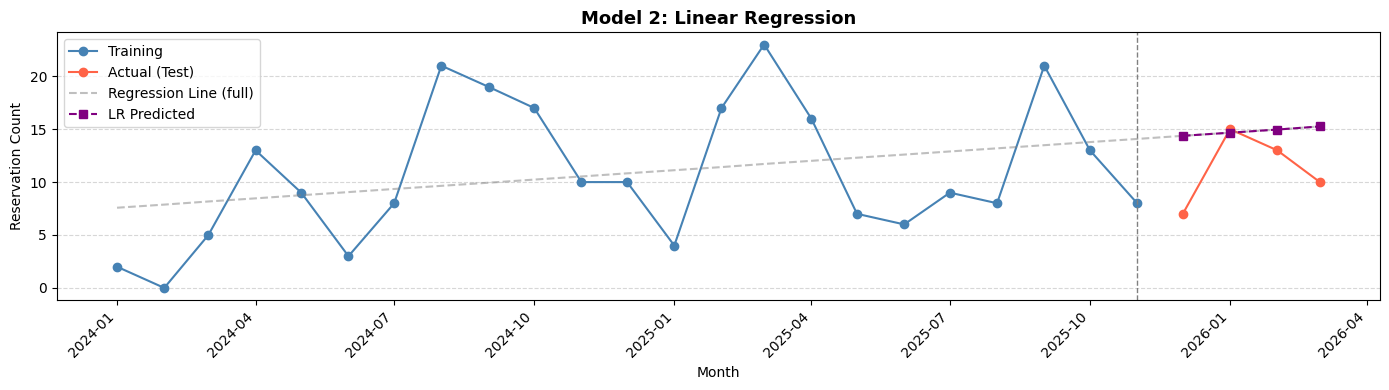

In [14]:
# Plot Linear Regression predictions vs actuals
all_idx = np.arange(1, len(df) + 1).reshape(-1, 1)
all_preds = lr_model.predict(all_idx)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['reservation_count'], marker='o', color='steelblue', label='Training')
ax.plot(test.index, test['reservation_count'], marker='o', color='tomato', label='Actual (Test)')
ax.plot(df.index, all_preds, linestyle='--', color='gray', alpha=0.5, label='Regression Line (full)')
ax.plot(test.index, lr_pred_series, marker='s', linestyle='--', color='purple', label='LR Predicted')
ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1)
ax.set_title('Model 2: Linear Regression', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_model2_linear_regression.png', dpi=150)
plt.show()

---
## Model 3: SARIMA (Improved)

**How it works:** SARIMA stands for Seasonal AutoRegressive Integrated Moving Average. It captures trend, seasonality, and autocorrelation (how past values influence future ones) all at once.

**Improved configuration applied from model-improvement notebook:**
- `ORDER = (1, 1, 1)`
- `SEASONAL_ORDER = (1, 0, 1, 6)`

This uses the observed semester cycle (`s=6`) and the best-performing SARIMA structure from your improvement tests.

In [15]:
# Improved SARIMA settings from emc_model_improvement.ipynb
ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 0, 1, 6)

print(f'SARIMA order          : {ORDER}')
print(f'SARIMA seasonal order : {SEASONAL_ORDER}')
print('(Applied improved model configuration)')
print()
print('Fitting SARIMA model...')

sarima_model = SARIMAX(
    train['reservation_count'],
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print('SARIMA model fitted successfully.')
print()
print(sarima_fit.summary())

SARIMA order          : (1, 1, 1)
SARIMA seasonal order : (1, 0, 1, 6)
(Applied improved model configuration)

Fitting SARIMA model...
SARIMA model fitted successfully.

                                     SARIMAX Results                                     
Dep. Variable:                 reservation_count   No. Observations:                   23
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 6)   Log Likelihood                 -42.049
Date:                           Wed, 15 Apr 2026   AIC                             94.098
Time:                                   05:43:55   BIC                             97.293
Sample:                               01-01-2024   HQIC                            93.802
                                    - 11-01-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

In [16]:
# Forecast the test period
sarima_forecast = sarima_fit.forecast(steps=TEST_SIZE)
sarima_pred_series = pd.Series(sarima_forecast.values, index=test.index)

print(f'=== Model 3: SARIMA {ORDER} x {SEASONAL_ORDER} ===')
print(f'  Month       Actual   Predicted')
for i, idx in enumerate(test.index):
    print(f'  {idx.strftime("%b %Y")}    {test["reservation_count"].iloc[i]:>6}   {sarima_forecast.values[i]:>9.2f}')
print()
sarima_result = compute_errors(test['reservation_count'], sarima_forecast.values, f'SARIMA{ORDER}x{SEASONAL_ORDER}')
results.append(sarima_result)

=== Model 3: SARIMA (1, 1, 1) x (1, 0, 1, 6) ===
  Month       Actual   Predicted
  Dec 2025         7        7.77
  Jan 2026        15       13.40
  Feb 2026        13        9.10
  Mar 2026        10       16.43

  MAE      = 3.1735   (avg absolute error per month)
  RMSE     = 3.8618   (penalizes large errors more)
  MASE     = 0.5541
  Dir.Acc% = 66.7%
  Var.Ratio= 1.2912
  PearsonR = 0.3024


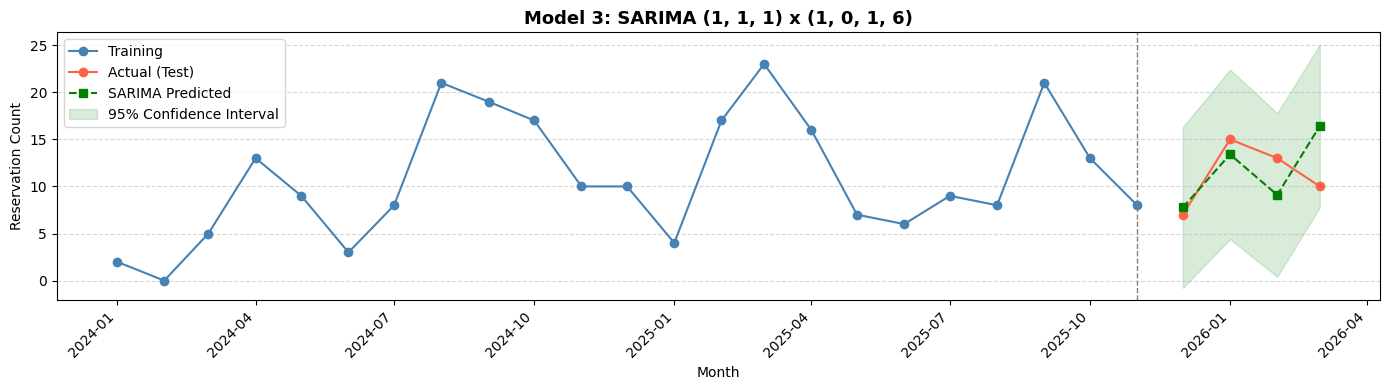

In [17]:
# Plot SARIMA predictions vs actuals
# Get confidence intervals for the forecast
forecast_obj = sarima_fit.get_forecast(steps=TEST_SIZE)
conf_int = forecast_obj.conf_int()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['reservation_count'], marker='o', color='steelblue', label='Training')
ax.plot(test.index, test['reservation_count'], marker='o', color='tomato', label='Actual (Test)')
ax.plot(test.index, sarima_pred_series, marker='s', linestyle='--', color='green', label='SARIMA Predicted')
ax.fill_between(test.index,
                conf_int.iloc[:, 0],
                conf_int.iloc[:, 1],
                color='green', alpha=0.15, label='95% Confidence Interval')
ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1)
ax.set_title(f'Model 3: SARIMA {ORDER} x {SEASONAL_ORDER}', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_model3_sarima.png', dpi=150)
plt.show()

---
## Model 4: Seasonal Naive

**How it works:** Repeats the value from the same season in the previous cycle.
For your EMC data, we use the semester cycle length = 6.

In [18]:
SEASON_LENGTH = 6

if len(train) < SEASON_LENGTH:
    raise ValueError(f'Training data must be at least {SEASON_LENGTH} months for seasonal naive.')

seasonal_naive_predictions = train['reservation_count'].iloc[-SEASON_LENGTH:-SEASON_LENGTH + TEST_SIZE].values
seasonal_naive_pred_series = pd.Series(seasonal_naive_predictions, index=test.index)

print(f'=== Model 4: Seasonal Naive (season_length={SEASON_LENGTH}) ===')
print('  Month       Actual   Predicted')
for i, idx in enumerate(test.index):
    print(f'  {idx.strftime("%b %Y")}    {test["reservation_count"].iloc[i]:>6}   {seasonal_naive_predictions[i]:>9.2f}')
print()
seasonal_naive_result = compute_errors(
    test['reservation_count'], seasonal_naive_predictions, f'Seasonal Naive (s={SEASON_LENGTH})'
 )
results.append(seasonal_naive_result)

=== Model 4: Seasonal Naive (season_length=6) ===
  Month       Actual   Predicted
  Dec 2025         7        6.00
  Jan 2026        15        9.00
  Feb 2026        13        8.00
  Mar 2026        10       21.00

  MAE      = 5.7500   (avg absolute error per month)
  RMSE     = 6.7639   (penalizes large errors more)
  MASE     = 1.0040
  Dir.Acc% = 66.7%
  Var.Ratio= 3.7551
  PearsonR = -0.0562


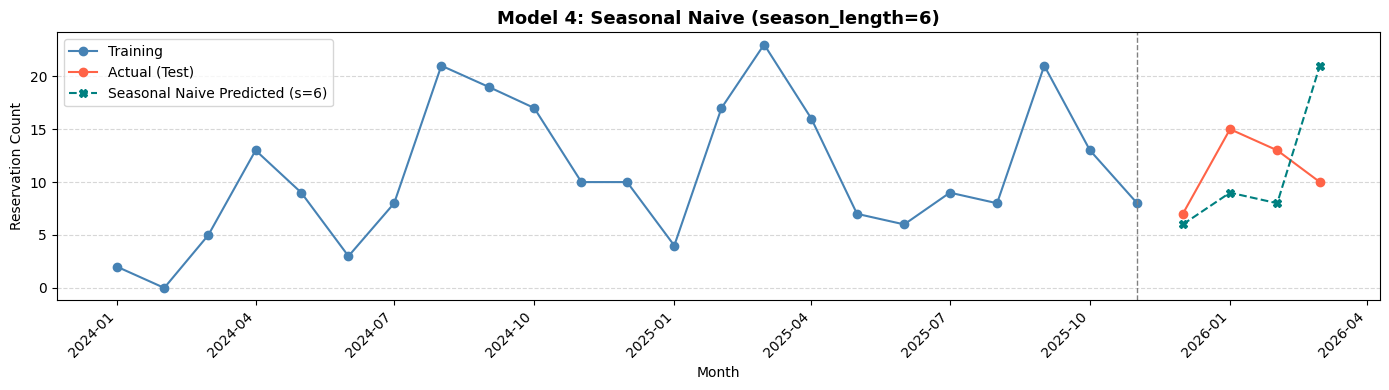

In [19]:
# Plot Seasonal Naive predictions vs actuals
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['reservation_count'], marker='o', color='steelblue', label='Training')
ax.plot(test.index, test['reservation_count'], marker='o', color='tomato', label='Actual (Test)')
ax.plot(test.index, seasonal_naive_pred_series, marker='X', linestyle='--', color='teal',
        label=f'Seasonal Naive Predicted (s={SEASON_LENGTH})')
ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1)
ax.set_title(f'Model 4: Seasonal Naive (season_length={SEASON_LENGTH})', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_model4_seasonal_naive.png', dpi=150)
plt.show()

---
## Model 5: Holt-Winters (Exponential Smoothing)

**How it works:** Holt-Winters can model level, trend, and seasonality.
Here we explicitly test additive trend + additive seasonality with semester cycle `s=6`.

In [20]:
# Compare Holt-Winters variants including additive trend + additive seasonality (s=6)
print('=' * 78)
print('MODEL 5: HOLT-WINTERS VARIANTS (ADDITIVE TREND + SEASONALITY)')
print('=' * 78)

SEASONAL_PERIODS_HW = 6

hw_variants = [
    {'name': 'HW Add Trend + Add Seasonal (s=6)',
     'trend': 'add',
     'seasonal': 'add',
     'damped_trend': False,
     'seasonal_periods': SEASONAL_PERIODS_HW},

    {'name': 'HW Add Trend + Add Seasonal + Damped (s=6)',
     'trend': 'add',
     'seasonal': 'add',
     'damped_trend': True,
     'seasonal_periods': SEASONAL_PERIODS_HW},

    {'name': 'HW Level Only (SES baseline)',
     'trend': None,
     'seasonal': None,
     'damped_trend': False,
     'seasonal_periods': None},
]

hw_comparison_results = []

for variant in hw_variants:
    try:
        model = ExponentialSmoothing(
            train['reservation_count'],
            trend=variant['trend'],
            seasonal=variant['seasonal'],
            damped_trend=variant['damped_trend'],
            seasonal_periods=variant['seasonal_periods'],
            initialization_method='estimated'
        )
        fit = model.fit(optimized=True)
        forecast = fit.forecast(TEST_SIZE)

        print(f"\n--- {variant['name']} ---")
        print(f"  trend={variant['trend']}  seasonal={variant['seasonal']}  damped={variant['damped_trend']}  s={variant['seasonal_periods']}")
        print('  Month       Actual   Predicted')
        for i, idx in enumerate(test.index):
            print(f'  {idx.strftime("%b %Y")}    {test["reservation_count"].iloc[i]:>6}   {forecast.values[i]:>9.2f}')
        print()

        metrics = compute_errors(test['reservation_count'], forecast.values, variant['name'])
        metrics['Variant'] = variant['name']
        metrics['ModelFit'] = fit
        metrics['Forecast'] = forecast
        hw_comparison_results.append(metrics)

    except Exception as e:
        print(f"\n--- {variant['name']} ---")
        print(f'  Error: {str(e)}')

# Select best variant by MAE
hw_comparison_df = pd.DataFrame(hw_comparison_results).sort_values('MAE').reset_index(drop=True)
best_variant = hw_comparison_df.iloc[0]

print('\n' + '=' * 78)
print(f"BEST HOLT-WINTERS VARIANT: {best_variant['Variant']}")
print(f"  MAE={best_variant['MAE']}  RMSE={best_variant['RMSE']}  MASE={best_variant['MASE']}")
print(f"  Dir.Acc%={best_variant['Dir.Acc%']}  Var.Ratio={best_variant['Var.Ratio']}  Pearson R={best_variant['Pearson R']}")
print('=' * 78)

# Use the best variant for final forecasts and results
hw_forecast = best_variant['Forecast']
hw_pred_series = pd.Series(hw_forecast.values, index=test.index)

print(f"\n=== Model 5: Holt-Winters - Final Selection ===")
print('  Month       Actual   Predicted')
for i, idx in enumerate(test.index):
    print(f'  {idx.strftime("%b %Y")}    {test["reservation_count"].iloc[i]:>6}   {hw_forecast.values[i]:>9.2f}')
print()
hw_result = {k: best_variant[k] for k in ['Model', 'MAE', 'RMSE', 'MASE', 'Dir.Acc%', 'Var.Ratio', 'Pearson R']}
results.append(hw_result)

MODEL 5: HOLT-WINTERS VARIANTS (ADDITIVE TREND + SEASONALITY)

--- HW Add Trend + Add Seasonal (s=6) ---
  trend=add  seasonal=add  damped=False  s=6
  Month       Actual   Predicted
  Dec 2025         7        6.36
  Jan 2026        15        7.83
  Feb 2026        13       13.58
  Mar 2026        10       19.08

  MAE      = 4.3669   (avg absolute error per month)
  RMSE     = 5.8005   (penalizes large errors more)
  MASE     = 0.7625
  Dir.Acc% = 33.3%
  Var.Ratio= 2.7610
  PearsonR = 0.0366

--- HW Add Trend + Add Seasonal + Damped (s=6) ---
  trend=add  seasonal=add  damped=True  s=6
  Month       Actual   Predicted
  Dec 2025         7        7.94
  Jan 2026        15        9.57
  Feb 2026        13       14.56
  Mar 2026        10       19.45

  MAE      = 4.3419   (avg absolute error per month)
  RMSE     = 5.5228   (penalizes large errors more)
  MASE     = 0.7581
  Dir.Acc% = 33.3%
  Var.Ratio= 2.2128
  PearsonR = 0.0610

--- HW Level Only (SES baseline) ---
  trend=None  se

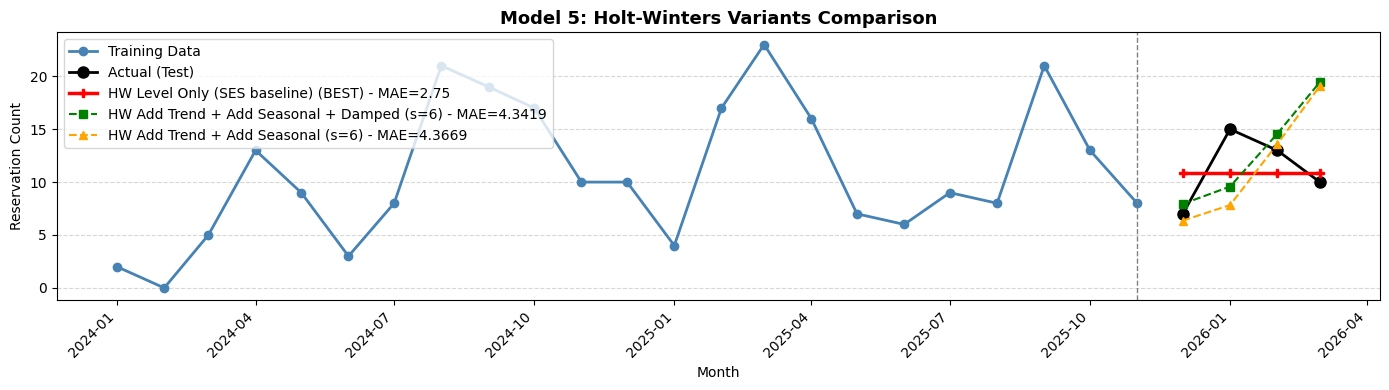

Saved: plot_model5_holt_winters_variants.png


In [21]:
# Plot all three Holt-Winters variants + actual for comparison
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(train.index, train['reservation_count'], marker='o', color='steelblue', 
        label='Training Data', linewidth=2)
ax.plot(test.index, test['reservation_count'], marker='o', color='black', 
        label='Actual (Test)', linewidth=2, markersize=8)

# Plot all three variants
colors = ['red', 'green', 'orange']
for i, row in hw_comparison_df.iterrows():
    variant_name = row['Variant']
    forecast_vals = row['Forecast'].values
    mae_val = row['MAE']
    
    # Highlight the best one
    if row['Variant'] == best_variant['Variant']:
        marker = 'P'
        line_style = '-'
        line_width = 2.5
        label = f"{variant_name} (BEST) - MAE={mae_val}"
    else:
        marker = 's' if i == 1 else '^'
        line_style = '--'
        line_width = 1.5
        label = f"{variant_name} - MAE={mae_val}"
    
    ax.plot(test.index, forecast_vals, marker=marker, linestyle=line_style, 
            color=colors[i], linewidth=line_width, label=label, markersize=6)

ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1)
ax.set_title('Model 5: Holt-Winters Variants Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_model5_holt_winters_variants.png', dpi=150)
plt.show()

print("Saved: plot_model5_holt_winters_variants.png")

---
## Step 7: Final Comparison

In [22]:
# Create clean results DataFrame from all models, removing duplicates
# Keep only the latest entry for each model type
results_clean = []
seen_models = set()

for result in reversed(results):
    model_base = result['Model'].split(' (')[0]  # Get base model name
    if model_base not in seen_models:
        seen_models.add(model_base)
        results_clean.append(result)

results_clean = list(reversed(results_clean))

metric_cols = ['Model', 'MAE', 'RMSE', 'MASE', 'Dir.Acc%', 'Var.Ratio', 'Pearson R']
results_df = pd.DataFrame(results_clean)[metric_cols].sort_values('MAE').reset_index(drop=True)
results_df['Rank (by MAE)'] = range(1, len(results_df) + 1)

print('=' * 90)
print('            FINAL MODEL COMPARISON — EXPANDED METRICS')
print('=' * 90)
print(results_df.to_string(index=False))
print('=' * 90)
print()

best_by_mae = results_df.sort_values('MAE').iloc[0]
print(f'🏆 BEST BY MAE      : {best_by_mae["Model"]}  (MAE={best_by_mae["MAE"]})')

if results_df['MASE'].notna().any():
    best_by_mase = results_df.dropna(subset=['MASE']).sort_values('MASE').iloc[0]
    print(f'🏆 BEST BY MASE     : {best_by_mase["Model"]}  (MASE={best_by_mase["MASE"]})')

if results_df['Dir.Acc%'].notna().any():
    best_by_dir = results_df.dropna(subset=['Dir.Acc%']).sort_values('Dir.Acc%', ascending=False).iloc[0]
    print(f'🏆 BEST BY DIR.ACC  : {best_by_dir["Model"]}  ({best_by_dir["Dir.Acc%"]}%)')

if results_df['Var.Ratio'].notna().any():
    tmp = results_df.dropna(subset=['Var.Ratio']).copy()
    tmp['vr_dist'] = (tmp['Var.Ratio'] - 1.0).abs()
    best_by_vr = tmp.sort_values('vr_dist').iloc[0]
    print(f'🏆 BEST VAR.RATIO   : {best_by_vr["Model"]}  (Var.Ratio={best_by_vr["Var.Ratio"]})')

if results_df['Pearson R'].notna().any():
    best_by_r = results_df.dropna(subset=['Pearson R']).sort_values('Pearson R', ascending=False).iloc[0]
    print(f'🏆 BEST PEARSON R   : {best_by_r["Model"]}  (Pearson R={best_by_r["Pearson R"]})')

print()
print('Guideline: lower MAE/RMSE/MASE is better; Dir.Acc% and Pearson R higher is better; Var.Ratio closer to 1.0 is better.')
print()

# Multi-metric final winner logic (weighted rank aggregation)
scoring_df = results_df.copy()
n_models = len(scoring_df)

# Build rank columns (1 = best)
scoring_df['rank_mae'] = scoring_df['MAE'].rank(method='min', ascending=True)
scoring_df['rank_mase'] = scoring_df['MASE'].rank(method='min', ascending=True) if scoring_df['MASE'].notna().any() else np.nan
scoring_df['rank_dir'] = scoring_df['Dir.Acc%'].rank(method='min', ascending=False) if scoring_df['Dir.Acc%'].notna().any() else np.nan
scoring_df['rank_vr'] = (scoring_df['Var.Ratio'] - 1.0).abs().rank(method='min', ascending=True) if scoring_df['Var.Ratio'].notna().any() else np.nan
scoring_df['rank_r'] = scoring_df['Pearson R'].rank(method='min', ascending=False) if scoring_df['Pearson R'].notna().any() else np.nan

# Weights prioritize accuracy + realistic dynamics
weights = {
    'rank_mae': 0.30,
    'rank_mase': 0.20,
    'rank_dir': 0.20,
    'rank_vr': 0.15,
    'rank_r': 0.15,
}

# Normalize weights if some metric columns are all-NaN
active_rank_cols = [c for c in weights.keys() if scoring_df[c].notna().any()]
active_weight_sum = sum(weights[c] for c in active_rank_cols)
normalized_weights = {c: (weights[c] / active_weight_sum) for c in active_rank_cols}

scoring_df['composite_score'] = 0.0
for c in active_rank_cols:
    scoring_df['composite_score'] += scoring_df[c].fillna(n_models) * normalized_weights[c]

final_winner = scoring_df.sort_values('composite_score').iloc[0]

print('=' * 90)
print('FINAL WINNER (MULTI-METRIC WEIGHTED LOGIC)')
print('=' * 90)
print(f"🥇 WINNER: {final_winner['Model']}")
print(f"Composite score (lower is better): {final_winner['composite_score']:.3f}")
print()
print('Weights used:')
for c in active_rank_cols:
    print(f"  {c}: {normalized_weights[c]:.2f}")
print()
print('Winner metric snapshot:')
print(f"  MAE={final_winner['MAE']}  RMSE={final_winner['RMSE']}  MASE={final_winner['MASE']}")
print(f"  Dir.Acc%={final_winner['Dir.Acc%']}  Var.Ratio={final_winner['Var.Ratio']}  Pearson R={final_winner['Pearson R']}")
print('=' * 90)

            FINAL MODEL COMPARISON — EXPANDED METRICS
                       Model    MAE   RMSE   MASE  Dir.Acc%  Var.Ratio  Pearson R  Rank (by MAE)
HW Level Only (SES baseline) 2.7500 3.0606 0.4802       0.0     0.0000        NaN              1
SARIMA(1, 1, 1)x(1, 0, 1, 6) 3.1735 3.8618 0.5541      66.7     1.2912     0.3024              2
           Linear Regression 3.7312 4.6354 0.6515      33.3     0.0119     0.2582              3
        Moving Average (w=2) 4.2500 4.7037 0.7421       0.0     0.5782    -0.5278              4
        Seasonal Naive (s=6) 5.7500 6.7639 1.0040      66.7     3.7551    -0.0562              5

🏆 BEST BY MAE      : HW Level Only (SES baseline)  (MAE=2.75)
🏆 BEST BY MASE     : HW Level Only (SES baseline)  (MASE=0.4802)
🏆 BEST BY DIR.ACC  : SARIMA(1, 1, 1)x(1, 0, 1, 6)  (66.7%)
🏆 BEST VAR.RATIO   : SARIMA(1, 1, 1)x(1, 0, 1, 6)  (Var.Ratio=1.2912)
🏆 BEST PEARSON R   : SARIMA(1, 1, 1)x(1, 0, 1, 6)  (Pearson R=0.3024)

Guideline: lower MAE/RMSE/MASE is be

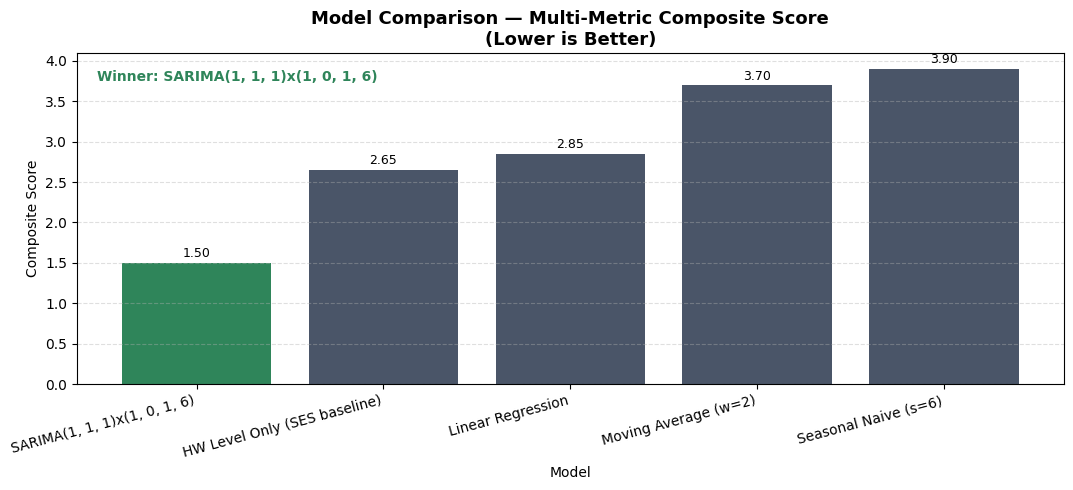

Saved: plot_model_comparison_multimetric.png


In [23]:
# Multi-metric comparison chart (uses weighted composite score from Step 7)
plot_df = scoring_df[['Model', 'composite_score', 'MAE', 'RMSE', 'MASE', 'Dir.Acc%', 'Var.Ratio', 'Pearson R']].copy()
plot_df = plot_df.sort_values('composite_score').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(plot_df['Model'], plot_df['composite_score'], color=['#2f855a' if i == 0 else '#4a5568' for i in range(len(plot_df))])

ax.set_title('Model Comparison — Multi-Metric Composite Score\n(Lower is Better)', fontsize=13, fontweight='bold')
ax.set_ylabel('Composite Score')
ax.set_xlabel('Model')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=15, ha='right')

# Annotate each bar with score
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.03, f'{h:.2f}', ha='center', va='bottom', fontsize=9)

# Emphasize the winner
winner_name = plot_df.iloc[0]['Model']
ax.text(0.02, 0.95, f'Winner: {winner_name}', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', color='#2f855a')

plt.tight_layout()
plt.savefig('plot_model_comparison_multimetric.png', dpi=150)
plt.show()
print('Saved: plot_model_comparison_multimetric.png')

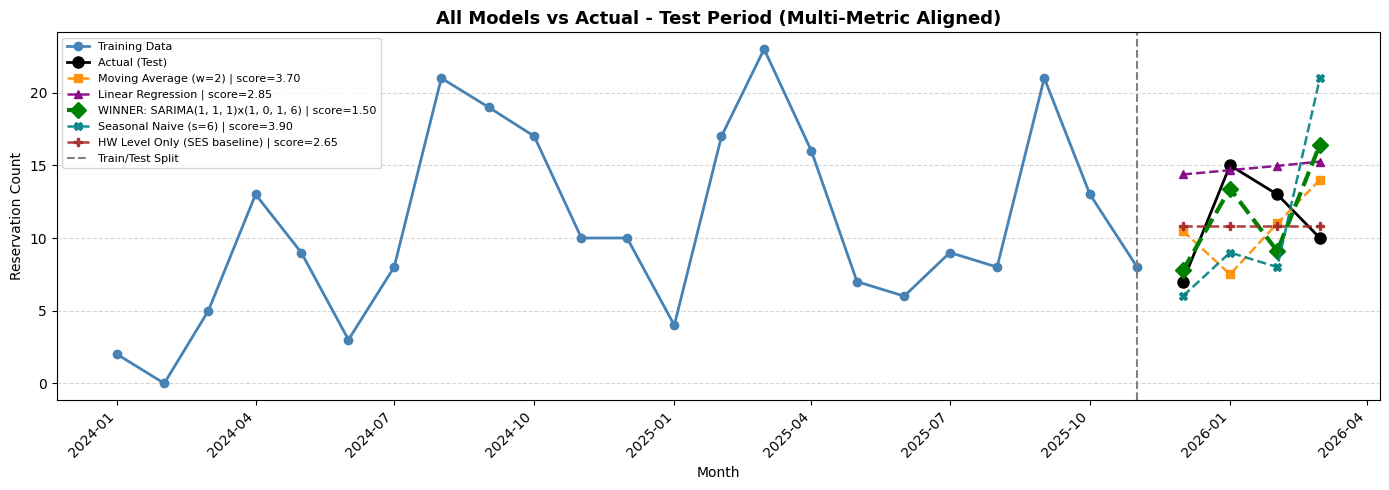

Saved: plot_all_models_comparison.png
Multi-metric winner highlighted: SARIMA(1, 1, 1)x(1, 0, 1, 6)


In [24]:
# All models on one chart vs actual test values (aligned with multi-metric scoring)
fig, ax = plt.subplots(figsize=(14, 5))

def norm_name(s):
    return ''.join(ch for ch in str(s).lower() if ch.isalnum())

score_map_raw = dict(zip(scoring_df['Model'], scoring_df['composite_score'])) if 'scoring_df' in globals() else {}
score_map = {norm_name(k): v for k, v in score_map_raw.items()}
winner_model_raw = final_winner['Model'] if 'final_winner' in globals() else None
winner_model = norm_name(winner_model_raw) if winner_model_raw is not None else None

# Plot historical + actual
ax.plot(
    train.index, train['reservation_count'], marker='o',
    color='steelblue', linewidth=2, label='Training Data'
 )
ax.plot(
    test.index, test['reservation_count'], marker='o',
    color='black', linewidth=2, markersize=8, label='Actual (Test)'
 )

# Build forecast series list
series_info = [
    ('Moving Average (w=2)', ma_pred_series, 'darkorange', 's'),
    ('Linear Regression', lr_pred_series, 'purple', '^'),
    ('SARIMA(1, 1, 1)x(1, 0, 1, 6)', sarima_pred_series, 'green', 'D'),
    ('Seasonal Naive (s=6)', seasonal_naive_pred_series, 'teal', 'X'),
    (str(best_variant['Variant']) if 'best_variant' in globals() else 'Holt-Winters', hw_pred_series, 'brown', 'P'),
]

for name, series, color, marker in series_info:
    key = norm_name(name)
    score = score_map.get(key, np.nan)
    is_winner = (winner_model == key)
    label = f"{name}"
    if not np.isnan(score):
        label += f" | score={score:.2f}"
    if is_winner:
        label = 'WINNER: ' + label

    ax.plot(
        test.index, series, marker=marker, linestyle='--', color=color,
        linewidth=3.0 if is_winner else 1.8, markersize=8 if is_winner else 6,
        alpha=1.0 if is_winner else 0.9, label=label
    )

ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1.5, label='Train/Test Split')
ax.set_title('All Models vs Actual - Test Period (Multi-Metric Aligned)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend(loc='upper left', fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_all_models_comparison.png', dpi=150)
plt.show()

print('Saved: plot_all_models_comparison.png')
if winner_model_raw is not None:
    print(f'Multi-metric winner highlighted: {winner_model_raw}')

## Step 8: Save Results to CSV

In [25]:
# Safe CSV writer: if target file is locked, write to a timestamped fallback file
from datetime import datetime

def safe_to_csv(df_obj, target_name):
    try:
        df_obj.to_csv(target_name, index=False)
        return target_name
    except PermissionError:
        stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        fallback = target_name.replace('.csv', f'_{stamp}.csv')
        df_obj.to_csv(fallback, index=False)
        return fallback

# Save expanded metrics table (sorted by MAE)
comparison_path = safe_to_csv(results_df, 'model_comparison_results.csv')

# Save multi-metric weighted comparison output
multimetric_cols = [
    'Model', 'MAE', 'RMSE', 'MASE', 'Dir.Acc%', 'Var.Ratio', 'Pearson R',
    'rank_mae', 'rank_mase', 'rank_dir', 'rank_vr', 'rank_r', 'composite_score'
]
comparison_multimetric_df = scoring_df[multimetric_cols].sort_values('composite_score').reset_index(drop=True)
multimetric_path = safe_to_csv(comparison_multimetric_df, 'model_comparison_multimetric_results.csv')

# Save predictions vs actuals for all models
predictions_df = pd.DataFrame({
    'month':              test.index.strftime('%Y-%m'),
    'actual':             test['reservation_count'].values,
    'moving_average':     np.round(ma_predictions, 2),
    'linear_regression':  np.round(lr_predictions, 2),
    'sarima':             np.round(sarima_forecast.values, 2),
    'seasonal_naive':     np.round(seasonal_naive_predictions, 2),
    'holt_winters':       np.round(hw_forecast.values, 2),
})
predictions_path = safe_to_csv(predictions_df, 'model_predictions.csv')

print('Saved:')
print(f'  {comparison_path}  <- expanded metrics table (sorted by MAE)')
print(f'  {multimetric_path}  <- weighted multi-metric scoring output')
print(f'  {predictions_path}  <- Actual vs Predicted for all models')
print()
print('Plots saved:')
for f in [
    'plot_full_series', 'plot_train_test_split',
    'plot_model1_moving_average', 'plot_model2_linear_regression',
    'plot_model3_sarima', 'plot_model4_seasonal_naive', 'plot_model5_holt_winters_variants',
    'plot_model_comparison_multimetric', 'plot_all_models_comparison'
]:
    print(f'  {f}.png')

Saved:
  model_comparison_results.csv  <- expanded metrics table (sorted by MAE)
  model_comparison_multimetric_results.csv  <- weighted multi-metric scoring output
  model_predictions.csv  <- Actual vs Predicted for all models

Plots saved:
  plot_full_series.png
  plot_train_test_split.png
  plot_model1_moving_average.png
  plot_model2_linear_regression.png
  plot_model3_sarima.png
  plot_model4_seasonal_naive.png
  plot_model5_holt_winters_variants.png
  plot_model_comparison_multimetric.png
  plot_all_models_comparison.png
